In [18]:
import os
import torch
import torchvision
import mlflow
import random
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from PIL import Image
from datetime import datetime
from torchvision.utils import save_image

# Special imports of above dependencies:
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models

In [19]:
# =====================================
# Random seed to ensure reproducibility
# =====================================
def set_seed(seed=42):
    # 1. Native python seed:
    random.seed(seed)

    # 2. Evironment python seed:
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Numpy seed:
    np.random.seed(seed)
    
    # 4. PyTorch seed (CPU)
    torch.manual_seed(seed)
    
    # 5. PyTorch seed (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. CuDNN deterministic for stability in math operations:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # Call seed function

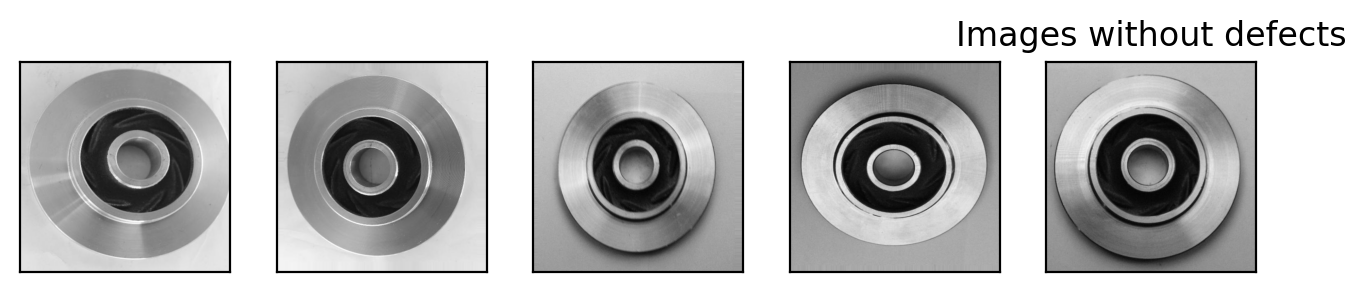

In [20]:
# Showing some samples of the dataset:
dataset_path_norm = "../data/raw/casting/casting_512x512/ok_front/" # Path to GOOD images dataset
dataset_path_def  = "../data/raw/casting/casting_512x512/def_front/" # Path to DEFECT images dataset
dataset_path_root = "../data/raw/casting/casting_512x512"


imgs_norm = os.listdir(os.path.join(dataset_path_norm)) # GOOD images
imgs_def  = os.listdir(os.path.join(dataset_path_def))  # DEFECT images

random.seed(42)

# Randomly sample 5 images per category:
samples_norm = random.sample(imgs_norm, 5)
samples_def  = random.sample(imgs_def, 5)

fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range(len(samples_norm)):
    ax = plt.subplot(2, 5, i + 1)
    imgNormPlot = Image.open(os.path.join(dataset_path_norm, samples_norm[i]))
    plt.imshow(imgNormPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.title("Images without defects", loc='center')
plt.show()

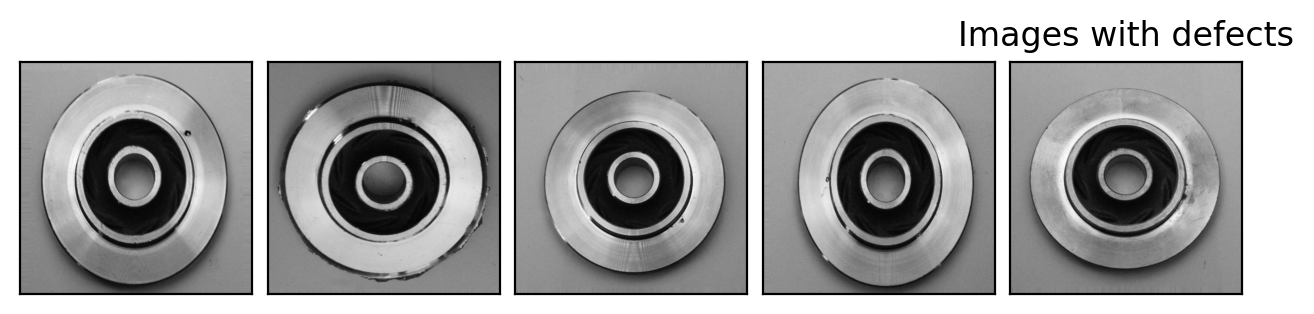

In [21]:
fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range (len(samples_def)):
    ax = plt.subplot(2, 5, i + 6)
    imgDefPlot = Image.open(os.path.join(dataset_path_def, samples_def[i]))
    plt.imshow(imgDefPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=-0.01, hspace=-0.01)

plt.title('Images with defects')
plt.show()

In [22]:
# Detecting if a GPU is available:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {torch.cuda.get_device_name(0)}") if device == "cuda" else print("No GPU available: Using CPU")

Device used: NVIDIA GeForce RTX 5080


In [23]:
class ResidualBlock(nn.Module):
    """ 
    Residual block that keeps resolution and channels intact. 
    Its sole function is to process and refine high-frequency textures. 
    """
    
    def __init__(self, channels):
        super().__init__()
        # First convolution (maintains size due to padding=1)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        
        # Second convolution
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x # Save the original input for the skip connection
        
        # Pass through the main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # Add the skip connection before the final activation
        out += residual 
        return F.relu(out)

In [24]:
# ################################################################################################################################
# ####################################### Architecture of the Encoder (GoogleNet Encoder): #######################################
# ################################################################################################################################

class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super().__init__()
        
        # Load the base GoogLeNet (without auxiliary classifiers nor weights)
        googlenet = models.googlenet(pretrained=False, aux_logits=False)
        
        # Extract all layers EXCEPT the last fully connected (FC) layer
        self.feature_extractor = nn.Sequential(*list(googlenet.children())[:-1]) # 1024-dimensional feature vector
        
        # Fusion: It only receives 1024 image features
        self.fc_fusion = nn.Linear(1024, 512)
        
        # Final mapping to the latent space z
        self.fc_mu = nn.Linear(512, latent_dims)
        self.fc_log_var = nn.Linear(512, latent_dims)

    def forward(self, x):
        # The input image is processed independently through GoogLeNet
        features = self.feature_extractor(x)    # Output: [batch, 1024, 1, 1]
        features = torch.flatten(features, 1)   # Output: [batch, 1024]
        
        fused = F.relu(self.fc_fusion(features))
        
        mu = self.fc_mu(fused)
        log_var = self.fc_log_var(fused)
        
        return mu, log_var

In [25]:
# ##################################################################################################################################
# ####################################### Architecture of the Decoder (GoogleNet Generator): #######################################
# ##################################################################################################################################

class Decoder(nn.Module):
    def __init__(self, latent_dims, num_classes=2):
        super().__init__()
        self.num_classes = num_classes
        
        # 1. Label Embedding: Increases the dimensionality of the conditional label
        self.label_emb = nn.Linear(num_classes, 64)
        
        # --- 2 Fully Connected (FC) Layers ---
        # Input size is now 128 (z) + 64 (embedded label) = 192
        self.fc1 = nn.Linear(latent_dims + 64, 1024)
        # Assuming the input before deconvolutions is 512 channels and 4x4 spatial size
        self.fc2 = nn.Linear(1024, 512 * 4 * 4) 
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(512, 4, 4))
        
        # --- 6 Deconvolution Layers (2-by-2 Upsampling) ---
        
        # SPATIAL INJECTION: Layer 1 | Channels: 512 (features) + 2 (labels) = 514 -> 256
        self.deconv1 = nn.ConvTranspose2d(512 + num_classes, 256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.res1 = ResidualBlock(256)
        
        # Layer 2: 3x3 Filter | Channels: 256 -> 256
        self.deconv2 = nn.ConvTranspose2d(256, 256, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        self.res2 = ResidualBlock(256)
        
        # Layer 3: 5x5 Filter | Channels: 256 -> 128
        self.deconv3 = nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.res3 = ResidualBlock(128)
        
        # Layer 4: 5x5 Filter | Channels: 128 -> 92
        self.deconv4 = nn.ConvTranspose2d(128, 92, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn4 = nn.BatchNorm2d(92)
        self.res4 = ResidualBlock(92)
        
        # Layer 5: 5x5 Filter | Channels: 92 -> 64
        self.deconv5 = nn.ConvTranspose2d(92, 64, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        self.res5 = ResidualBlock(64)
        
        # Layer 6: 5x5 Filter | Channels: 64 -> 3 (Final Image)
        self.deconv6 = nn.ConvTranspose2d(64, 3, kernel_size=5, stride=2, padding=2, output_padding=1)

    def forward(self, z, label):
        # 1. Embed the conditional label and concatenate it with the latent vector (z)
        label_embedded = F.relu(self.label_emb(label))
        x = torch.cat((z, label_embedded), dim=1)
        
        # Pass through the FC layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.unflatten(x) # Reshape into a spatial map of [batch, 512, 4, 4]
        
        # 2. DEEP SPATIAL INJECTION (Ensures the network retains class conditioning)
        # Expand the label [batch, 2] to a spatial map of [batch, 2, 4, 4]
        label_spatial = label.unsqueeze(2).unsqueeze(3)
        label_spatial = label_spatial.expand(-1, -1, x.size(2), x.size(3))
        
        # Concatenate the feature map with the label spatial map
        x = torch.cat((x, label_spatial), dim=1) # x is now [batch, 514, 4, 4]
        
        # Pass through Deconvolutions with Batch Normalization and ResNet blocks
        x = F.relu(self.bn1(self.deconv1(x)))
        x = self.res1(x)

        x = F.relu(self.bn2(self.deconv2(x)))
        x = self.res2(x)

        x = F.relu(self.bn3(self.deconv3(x)))
        x = self.res3(x)

        x = F.relu(self.bn4(self.deconv4(x)))
        x = self.res4(x)

        x = F.relu(self.bn5(self.deconv5(x)))
        x = self.res5(x)
        
        # The final layer uses Tanh for images in range [-1, 1], without BatchNorm
        x = torch.tanh(self.deconv6(x)) 
        
        return x

In [26]:
class CVAE(nn.Module):
    def __init__(self, latent_dims=100, num_classes=2):
        super().__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims, num_classes)

    def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)  # Compute standard deviation from log variance
        eps = torch.randn_like(std)     # Sample form standard normal distribution

        return mu + eps * std
    
    def forward(self, x, label):
        mu, log_var = self.encoder(x)
        z = self.reparametrize(mu, log_var)

        return self.decoder(z, label), mu, log_var

In [27]:
# ##################################################################################################################
# ####################################### Architecture of the Discriminator: #######################################
# ##################################################################################################################

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, num_classes=2):
        super(Discriminator, self).__init__()

        self.num_classes = num_classes

        self.feature_extractor = nn.Sequential(
            # Layer 1 --- Input: 3x256x256 -> Output: 64x128x128 ---
            nn.Conv2d(nc, ndf, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2 --- Input: 64x128x128 -> Output: 128x64x64 ---
            nn.Conv2d(ndf, ndf * 2, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3 --- Input: 128x64x64 -> Output: 256x32x32 ---
            nn.Conv2d(ndf * 2, ndf * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4 --- Input: 256x32x32 -> Output: 512x16x16 ---
            nn.Conv2d(ndf * 4, ndf * 8, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 5 --- Input: 512x16x16 -> Output: 1024x8x8 ---
            nn.Conv2d(ndf * 8, ndf * 16, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Classification layer (real/fake): Input 1024x8x8 -> Output 1x4x4 
        self.rf_classifier = nn.Conv2d(ndf * 16, 1, 4, stride=2, padding=1, bias=False) # 1 Neuron output for binary classification (real/fake)
        
        # Auxiliary classifier for the ACGAN (class prediction): Input 1024x8x8 -> Output 2 x 4 x 4
        self.aux_classifier = nn.Conv2d(ndf * 16, num_classes, 4, stride=2, padding=1, bias=False) # 2 Neurons output for class prediction (defect/no defect)

    def forward(self, x):
        features = self.feature_extractor(x)                                    # Extract features: [batch, 1024, 8, 8]
        output_rf = self.rf_classifier(features).view(x.size(0), -1).mean(1)    # Output real/fake: [batch, 1, 4, 4]
        output_cls = self.aux_classifier(features).mean([2, 3])                 # Output class prediction: [batch, 2, 4, 4]

        return output_rf, output_cls, features

In [28]:
# Function to add gaussian noise to the images:
def add_noise(inputs, epoch, max_epochs):
    noise_factor = max(0, 1.0 - (epoch / (max_epochs * 0.5))) # Zero at the middle of training
    std = 0.1 * noise_factor
    noise = torch.randn_like(inputs) * std
    
    return inputs + noise

In [29]:
# ######################################################################
# ######################### Training Function ##########################
# ######################################################################

def train_cvae_gan_epoch(
        dataloader,
        cvae,
        discriminator,
        optimizer_cvae,
        optimizer_discriminator,
        criterion_recon,
        criterion_feat,
        criterion_disc,
        criterion_aux,
        device,
        epoch,
        beta,
        gamma,
        n_epochs,
        warmup_epochs
):
    # Error accumlators:
    total_G_recon_loss = 0
    total_G_kld_loss = 0
    total_G_feat_loss = 0
    total_G_aux_loss = 0
    total_D_loss = 0
    total_D_aux_loss = 0

    # KL Annealing: Gradually increase the KL divergence weight from 0 to beta during warmup epochs:
    kl_weight = beta * min(1.0, epoch / max(1, warmup_epochs))

    # Set networks on training mode:
    cvae.train()
    discriminator.train()

    for _, (images, labels_idx) in enumerate(dataloader):
        # Prepare data:
        images = images.to(device) # [batch, 3, 256, 256]
        labels_idx = labels_idx.to(device) # [barch] (int: 0, 1)

        # Encode labels: [0, 1] -> [[1, 0], [0, 1]]
        labels_encoded = F.one_hot(labels_idx, num_classes=2).float().to(device)

        # Get the batch size:
        batch_size = images.size(0)

        # ############################################################################
        # ######################## TRAINING GENERATOR (CVAE): ########################
        # ############################################################################

        optimizer_cvae.zero_grad() # Clean gradients

        recon_images, mu, log_var = cvae(images, labels_encoded) # CVAE creates an image

        loss_G_recon = criterion_recon(recon_images, images) / batch_size # L1 loss for tanh
        loss_G_recon = loss_G_recon / 16 # 16 is an scale factor due to pixel increment od 256x256 instead of 64x64

        loss_G_kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size # Kullback-Leibler Divergence for std dist of latent space
        loss_G_feat = torch.tensor(0.0, device=device)
        loss_G_aux = torch.tensor(0.0, device=device)

        # Activate GAN only if epoch >= warmup epochs:
        if epoch >= warmup_epochs:
            # Deactivate gradients for distriminator:
            for param in discriminator.parameters():
                param.requires_grad = False
                
            # Feature matching: Obtain prediction and features:
            pred_fake_rf, pred_fake_cls,features_fake = discriminator(recon_images)

            # Get the real features with no gradients:
            with torch.no_grad():
               _, _, features_real = discriminator(images)

            loss_G_feat = criterion_feat(features_fake, features_real.detach()) # Feature matching loss: L2 loss for mean squared error
            loss_G_aux = criterion_aux(pred_fake_cls, labels_idx) # Auxiliary classification loss for ACGAN

        # Weighted sum for Generator:
        loss_G_total = loss_G_recon + (kl_weight * loss_G_kld) + (gamma * loss_G_feat) + (1.0 * loss_G_aux)

        # Backpropagation:
        loss_G_total.backward()
        optimizer_cvae.step()

        # ###############################################################################
        # ######################## TRAINING DISCRIMINATOR (CNN): ########################
        # ###############################################################################

        loss_D_total = torch.tensor(0.0, device=device) # Init loss_d as a tensor
        loss_D_aux_total = torch.tensor(0.0, device=device)

        if epoch >= warmup_epochs:
            # Activate gradients for discriminator:
            for param in discriminator.parameters():
                param.requires_grad = True

            optimizer_discriminator.zero_grad() # Clean gradients

            # Real samples:
            noisy_images = add_noise(images, epoch, n_epochs)
            pred_real_rf, pred_real_cls, _ = discriminator(noisy_images)
            label_real = torch.tensor(np.random.uniform(0.9, 1.0), device=device).float().expand_as(pred_real_rf)

            loss_D_real_rf = criterion_disc(pred_real_rf, label_real)
            loss_D_real_aux = criterion_aux(pred_real_cls, labels_idx)

            # Fake samples:
            noisy_fakes = add_noise(recon_images.detach(), epoch, n_epochs) # Detach to avoid backprop through generator
            pred_fake_rf, pred_fake_cls, _ = discriminator(noisy_fakes)
            label_fake = torch.tensor(np.random.uniform(0.0, 0.1), device=device).float().expand_as(pred_fake_rf)

            loss_D_fake_rf = criterion_disc(pred_fake_rf, label_fake)
            loss_D_fake_aux = criterion_aux(pred_fake_cls, labels_idx)

            # Discriminator loss:
            loss_D_aux_total = (loss_D_real_aux + loss_D_fake_aux) / 2
            loss_D_total = (loss_D_real_rf + loss_D_fake_rf) / 2 + (1.0 * loss_D_aux_total)

            # Backpropagation:
            loss_D_total.backward()
            optimizer_discriminator.step()

        # Update accumulators:
        total_G_recon_loss += loss_G_recon.item()
        total_G_kld_loss += loss_G_kld.item()
        total_G_feat_loss += loss_G_feat.item()
        total_G_aux_loss += loss_G_aux.item()
        total_D_loss += loss_D_total.item()
        total_D_aux_loss += loss_D_aux_total.item()

    # Means per epoch:
    n_batches = len(dataloader)

    return(
        total_G_recon_loss / n_batches,
        total_G_kld_loss / n_batches,
        total_G_feat_loss / n_batches,
        total_D_loss / n_batches,
        total_G_aux_loss / n_batches,
        total_D_aux_loss / n_batches
    )

In [30]:
ENABLE_TRAINING = False # Set to True to enable training, False to skip directly to generation and evaluation

# Architecture params:
MODEL_ARCH = "CVAE-GAN"
IMG_SIZE = 256
NUM_CLASSES = 2 # number of different classes

# Hyperparameters:
HP_BETA = 0.503033668184222           # Weight for KLD latent regularization
HP_GAMMA = 99.6197494133445         # Weight for GAN
HP_LR_G = 0.00019793200573311274        # Learning rate of generator
HP_LR_D = 1.0135214941842044e-05        # Learning rate of discriminator
HP_N_EPOCHS = 1000       # Total training epochs
HP_BATCH_SIZE = 64      # n (inputs) images per batch
HP_LATENT_DIMS = 128    # Size of latent space
HP_WEIGHT_DECAY = 1e-5  # Weight penalization for Adam Optimizer
HP_WARMUP_EPOCHS = 15   # Epochs to set HP_LR

# MLFlow information:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
EXPERIMENT_NAME = f"Synthetic_Defect_Generation_{MODEL_ARCH}"
RUN_NAME = f"Try: AC GAN for def / no-def classification - {timestamp}"

In [31]:
# Transforming the data and creating batches for training:
transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3) # Z-Score
])

# Create the dataloader from dataset:
dataset = torchvision.datasets.ImageFolder(
    root=dataset_path_root, 
    transform=transform
    )

print(f"Mapping classes: {dataset.class_to_idx}")

# Optimizing for GPU:

max_workers = os.cpu_count() # Number of CPU cores available

if device == "cuda":
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        num_workers=max_workers, # CPU threads loading the batches
        pin_memory=True, # Transfer form RAM to VRAM
        persistent_workers=True # Same CPU threads in every epoch
        )
    print("Optimizing batches using GPU")
else:
    train_dataloader = torch.utils.data.DataLoader(
        dataset=dataset, 
        batch_size=HP_BATCH_SIZE, 
        shuffle=True,
        )
    
print(f"Total images: {len(dataset)}")
print(f"Total batches per epoch: {len(train_dataloader)}")

Mapping classes: {'def_front': 0, 'ok_front': 1}
Optimizing batches using GPU
Total images: 1300
Total batches per epoch: 21


In [32]:
# Weight initilization for GAN:
def weights_init(m):
    # Preguntamos si es explícitamente una convolución o deconvolución
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
            
    # Preguntamos si es explícitamente una capa de Normalización
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# To save samples progress:
def save_samples(model, epoch, fixed_noise, fixed_label_good, fixed_label_bad, save_path):
    model.eval()

    with torch.no_grad():
        # Generate GOOD samples:
        sample_good = model.decoder(fixed_noise, fixed_label_good)

        # Generate DEFECT samples:
        sample_defect = model.decoder(fixed_noise, fixed_label_bad)

        # Concatenate and save:
        sample = torch.cat([sample_good, sample_defect], dim=0)
        sample = sample * 0.5 + 0.5 # De-normalize for visualization: (-1, 1) -> (0, 1)

        sample = F.interpolate(sample, scale_factor=1, mode='nearest')

        filepath = os.path.join(save_path, f'cvae_gan_epoch_{epoch}.png')
        save_image(sample, filepath, nrow=5)

        # Save to mlflow:
        mlflow.log_artifact(filepath, artifact_path='cvae_gan_generated_images')

        # Remove from local:
        os.remove(filepath)

    model.train()

In [33]:
# ##################################################################
# ########################### Training ############################
# ##################################################################

if ENABLE_TRAINING:

    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=RUN_NAME):
        print("Logging parameteres to MLFlow...")
        hyperparams = {
            'architecture': MODEL_ARCH,
            'img_size': IMG_SIZE,
            'num_classes': NUM_CLASSES,
            'beta_kld': HP_BETA,
            'gamma_gan': HP_GAMMA,
            'learning_rate_generator': HP_LR_G,
            'learning_rate_discriminator': HP_LR_D,
            'n_epochs': HP_N_EPOCHS,
            'batch_size': HP_BATCH_SIZE,
            'latent_dims': HP_LATENT_DIMS,
            'adam_weight_decay': HP_WEIGHT_DECAY,
            'warmup_epochs': HP_WARMUP_EPOCHS
        }
        mlflow.log_params(hyperparams)

        print(f"Starting MLFlow Run: {mlflow.active_run().info.run_name}")

        # --- Init models ---
        cvae = CVAE(HP_LATENT_DIMS, num_classes=NUM_CLASSES).to(device)
        discriminator = Discriminator(num_classes=NUM_CLASSES).to(device)

        # --- Init weights ---
        cvae.apply(weights_init)
        discriminator.apply(weights_init)

        # --- Set Optimizers ---
        optimizer_G = optim.Adam(cvae.parameters(), lr=HP_LR_G, betas=(0.5, 0.9999), weight_decay=HP_WEIGHT_DECAY) # Optimizer for generator
        optimizer_D = optim.Adam(discriminator.parameters(), lr=HP_LR_D, betas=(0.5, 0.9999), weight_decay=HP_WEIGHT_DECAY) # Optimizer for discriminator

        # optimizer_G = optim.RMSprop(cvae.parameters(), lr=HP_LR_G, alpha=0.9, weight_decay=HP_WEIGHT_DECAY) # Optimizer for generator
        # optimizer_D = optim.RMSprop(discriminator.parameters(), lr=HP_LR_D, alpha=0.9, weight_decay=HP_WEIGHT_DECAY) # Optimizer for discriminator
        
        # --- Loss Functions ---
        criterion_feat = nn.L1Loss() # L1 Loss for reconstruction (when using Tanh)
        criterion_recon = nn.MSELoss(reduction='sum') # Feature matching loss 
        criterion_disc = nn.BCEWithLogitsLoss() # Binary Cross Entropy with Logits for Discriminator (when not using Sigmoid)
        criterion_aux = nn.CrossEntropyLoss() # Cross Entropy for ACGAN auxiliary classifier

        # --- Fixed noise images ---
        fixed_noise = torch.randn(5, HP_LATENT_DIMS).to(device)
        fixed_label_bad = torch.tensor([1.0, 0.0]).repeat(5, 1).to(device)
        fixed_label_good = torch.tensor([0.0, 1.0]).repeat(5, 1).to(device)
        
        # ########################### Training Loop ############################
        
        print("Training...")

        for epoch in range(HP_N_EPOCHS):
            avg_G_recon_loss, avg_G_kld_loss, avg_G_feat_loss, avg_D_loss, avg_G_aux_loss, avg_D_aux_loss = train_cvae_gan_epoch(
                train_dataloader,
                cvae,
                discriminator,
                optimizer_G,
                optimizer_D,
                criterion_recon,
                criterion_feat,
                criterion_disc,
                criterion_aux,
                device,
                epoch,
                HP_BETA,
                HP_GAMMA,
                HP_N_EPOCHS,
                HP_WARMUP_EPOCHS
            )

            # Logging metrics to mlflow:
            mlflow.log_metrics({
                'loss_G_recon': avg_G_recon_loss,
                'loss_G_kld': avg_G_kld_loss,
                'loss_G_feat': avg_G_feat_loss,
                'loss_Disc': avg_D_loss,
                'loss_G_aux': avg_G_aux_loss,
                'loss_D_aux': avg_D_aux_loss
            }, step=epoch)

            save_path = '../reports/figures/cvae_gan'

            print(f"Epoch [{epoch+1}/{HP_N_EPOCHS}] | Recon Loss G: {avg_G_recon_loss:.4f} | Feat Match Loss G: {avg_G_feat_loss:.4f} | KLD Loss G: {avg_G_kld_loss:.4f} | Disc Loss D: {avg_D_loss:.4f} | Aux Loss G: {avg_G_aux_loss:.4f} | Aux Loss D: {avg_D_aux_loss:.4f} ")

            if epoch % 10 == 0 or epoch == HP_N_EPOCHS -1:
                save_samples(cvae, epoch, fixed_noise, fixed_label_good, fixed_label_bad, save_path)
        

        print("Training finished.")

        # Temporary saving the models to local disk
        save_path_G = '../models/cvae_gan/cvae_gen.pth'
        save_path_D = '../models/cvae_gan/dcgan_disc.pth'
        
        torch.save(cvae.state_dict(), save_path_G)
        torch.save(discriminator.state_dict(), save_path_D)
        
        # Logging the definitive models to MLflow
        mlflow.log_artifact(save_path_G, artifact_path='models')
        mlflow.log_artifact(save_path_D, artifact_path='models')

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# ==============================================================================
# 1. Dynamic Centroid Extraction (Without guessing indices)
# ==============================================================================

@torch.no_grad()
def calculate_latent_centroids_dynamic(dataloader, dataset, encoder, device):
    print("Mapping the latent space...")
    encoder.eval()
    
    # Extract the EXACT indices PyTorch assigned to your folders
    idx_def = dataset.class_to_idx['def_front']
    idx_ok = dataset.class_to_idx['ok_front']
    print(f"PyTorch Dictionary -> Defect: {idx_def} | OK: {idx_ok}")

    mu_def_list = []
    mu_ok_list = []

    for images, labels_idx in dataloader:
        images = images.to(device)
        
        # NOTE: ACGAN blind encoder only takes the image
        mu, _ = encoder(images)
        
        for i in range(len(labels_idx)):
            # Use dynamic indices to avoid mistakes
            if labels_idx[i] == idx_def: 
                mu_def_list.append(mu[i].cpu().numpy())
            elif labels_idx[i] == idx_ok:
                mu_ok_list.append(mu[i].cpu().numpy())

    # Mathematical averages (Centroids)
    centroid_def = np.mean(mu_def_list, axis=0)
    centroid_ok = np.mean(mu_ok_list, axis=0)
    
    print(f"Extracted {len(mu_def_list)} defect vectors and {len(mu_ok_list)} OK vectors.")

    return torch.tensor(centroid_def).float().to(device), torch.tensor(centroid_ok).float().to(device)

# Load encoder:
cvae = CVAE(HP_LATENT_DIMS, num_classes=NUM_CLASSES).to(device)
cvae.load_state_dict(torch.load('../models/cvae_gan/cvae_gen.pth', map_location=device))
cvae.eval()

# Execute the extraction
centroid_def, centroid_ok = calculate_latent_centroids_dynamic(train_dataloader, dataset, cvae.encoder, device)

# CALCULATE THE DIRECTIONAL VECTOR (Direction: from OK to Defect)
vector_defect = centroid_def - centroid_ok
print("Defect vector calculated successfully!")

Mapping the latent space...
PyTorch Dictionary -> Defect: 0 | OK: 1
Extracted 781 defect vectors and 519 OK vectors.
Defect vector calculated successfully!


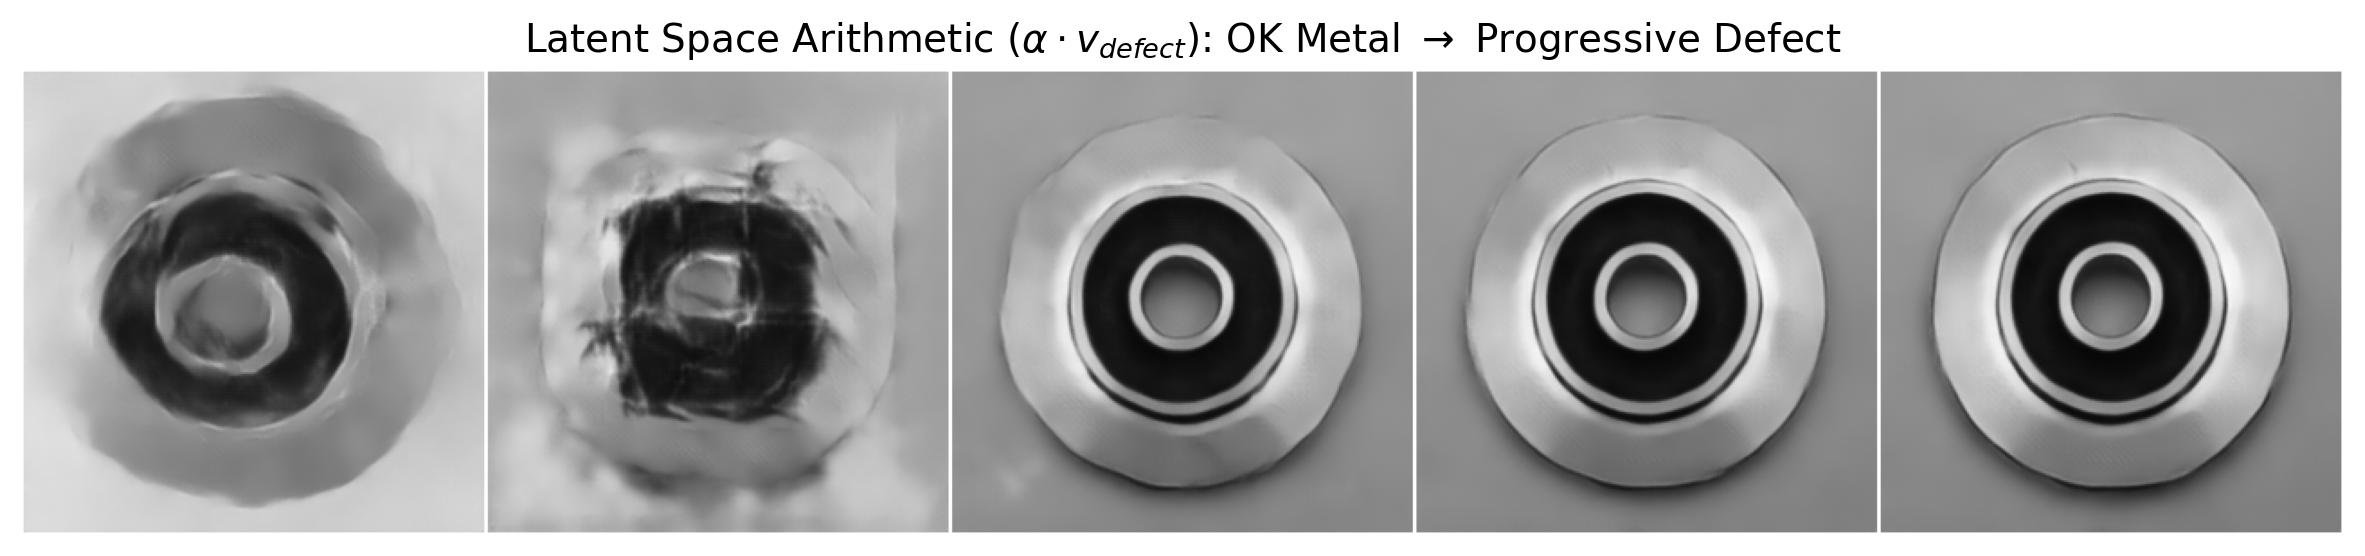

In [ ]:
def generate_defect_progression_fixed(decoder, centroid_base, direction_vector, label_ok, label_def, device):
    decoder.eval()
    alphas = [0.0, 0.5, 1.0, 1.5, 2.0]
    generated_images = []
    with torch.no_grad():
        for alpha in alphas:
            z_modified = (centroid_base + alpha * direction_vector).unsqueeze(0)
            # Interpolate labels: Start with OK and gradually move towards DEFECT as alpha increases
            label_interp = (1 - min(alpha, 1.0)) * label_ok + min(alpha, 1.0) * label_def
            img_tensor = decoder(z_modified, label_interp)
            generated_images.append(img_tensor)
    progression_tensor = torch.cat(generated_images, dim=0)
    progression_tensor = progression_tensor * 0.5 + 0.5
    grid = make_grid(progression_tensor, nrow=5, padding=2, pad_value=1.0)
    grid_np = grid.cpu().numpy().transpose((1, 2, 0))
    plt.figure(figsize=(15, 4), dpi=200)
    plt.imshow(grid_np)
    plt.axis('off')
    plt.title(r"Latent Space Arithmetic ($\alpha \cdot v_{defect}$): OK Metal $\rightarrow$ Progressive Defect", fontsize=14)
    plt.show()
 
 
# Labels
idx_ok  = dataset.class_to_idx['ok_front']
idx_def = dataset.class_to_idx['def_front']
 
 
label_ok_single  = torch.zeros(1, 2).to(device)
label_ok_single[0, idx_ok] = 1.0
 
label_bad_single = torch.zeros(1, 2).to(device)
label_bad_single[0, idx_def] = 1.0
 
# Generate the progression with dynamic label interpolation
generate_defect_progression_fixed(
    decoder=cvae.decoder,
    centroid_base=centroid_ok,
    direction_vector=vector_defect,
    label_ok=label_ok_single,
    
    label_def=label_bad_single,
    device=device
)